In [1]:
import sys
import os

PROJECT_ROOT = r"c:\Projects\TEYZIX-CORE-INTERNSHIP\task-3_Telco_Churn_System"
sys.path.append(PROJECT_ROOT)

In [3]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'C:\Program Files\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

C:\Users\10\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = joblib.load("../models/logistic_model.pkl")

In [4]:
data = pd.read_csv(
    "../dataset/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# convert target column
data["Churn"] = data["Churn"].str.strip().map({
    "Yes": 1,
    "No": 0
})

# remove customer id
data.drop(columns=["customerID"], inplace=True)

# fix TotalCharges
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

# one-hot encoding
data = pd.get_dummies(data, drop_first=True)

# split features + target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# ensure numeric
X = X.astype(float)

print(X.shape)

(7043, 30)


In [6]:
explainer = shap.LinearExplainer(model, X)

shap_values = explainer.shap_values(X)

print(type(shap_values))

<class 'numpy.ndarray'>


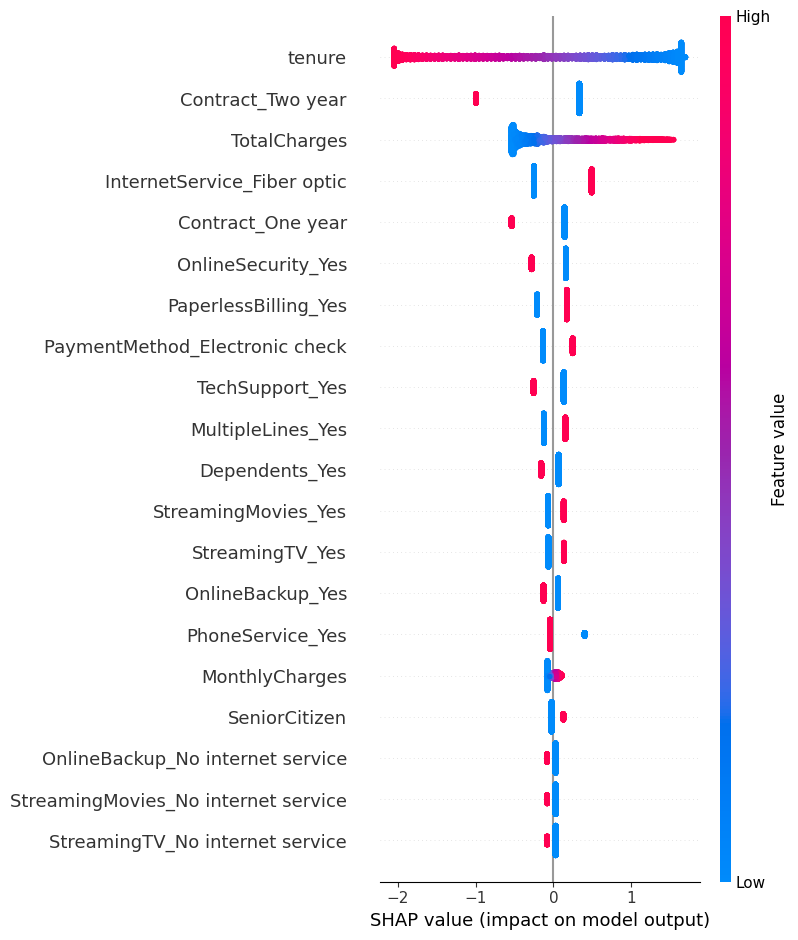

In [7]:
shap.summary_plot(shap_values, X)

## PER-CUSTOMER EXPLANATION

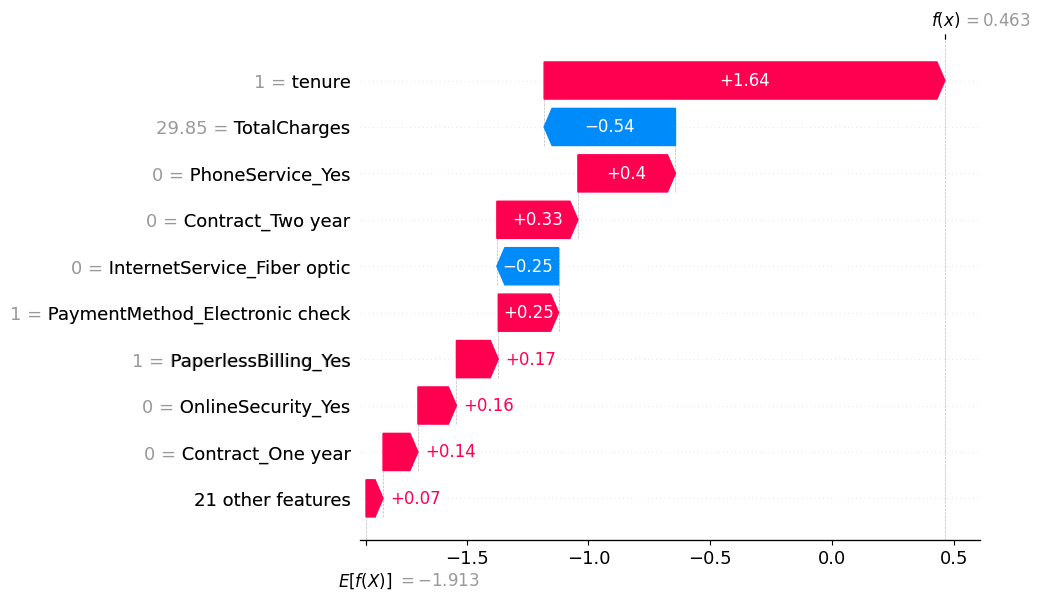

In [8]:
customer_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X.iloc[customer_index],
        feature_names=X.columns
    )
)

## TOP 3 CHURN DRIVERS

In [9]:
customer_index = 0

customer_shap = pd.DataFrame({
    "feature": X.columns,
    "shap_value": shap_values[customer_index]
})

customer_shap["abs_value"] = customer_shap["shap_value"].abs()

top_features = customer_shap.sort_values(
    by="abs_value",
    ascending=False
).head(3)

top_features

,feature,shap_value,abs_value
1,tenure,1.644759,1.644759
3,TotalCharges,-0.539104,0.539104
7,PhoneService_Yes,0.400424,0.400424


## BUSINESS EXPLANATION

In [10]:
print("Why is this customer at risk?\n")

for feature in top_features["feature"]:
    print("-", feature)

Why is this customer at risk?

- tenure
- TotalCharges
- PhoneService_Yes


In [11]:
print("Customer Churn Explanation Report")
print("----------------------------------")

for index, row in top_features.iterrows():

    feature = row["feature"]
    value = row["shap_value"]

    if value > 0:
        impact = "increases churn risk"
    else:
        impact = "reduces churn risk"

    print(f"{feature} → {impact}")

Customer Churn Explanation Report
----------------------------------
tenure → increases churn risk
TotalCharges → reduces churn risk
PhoneService_Yes → increases churn risk
